In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from numba import njit
import matplotlib.colors as mcolors
%matplotlib inline

#### Klausmeier model simulation
----

Simulation running...
snapshot t=0
snapshot t=56
snapshot t=111
snapshot t=167
snapshot t=222
snapshot t=278
snapshot t=333
snapshot t=389
snapshot t=444
Simulation concluded.


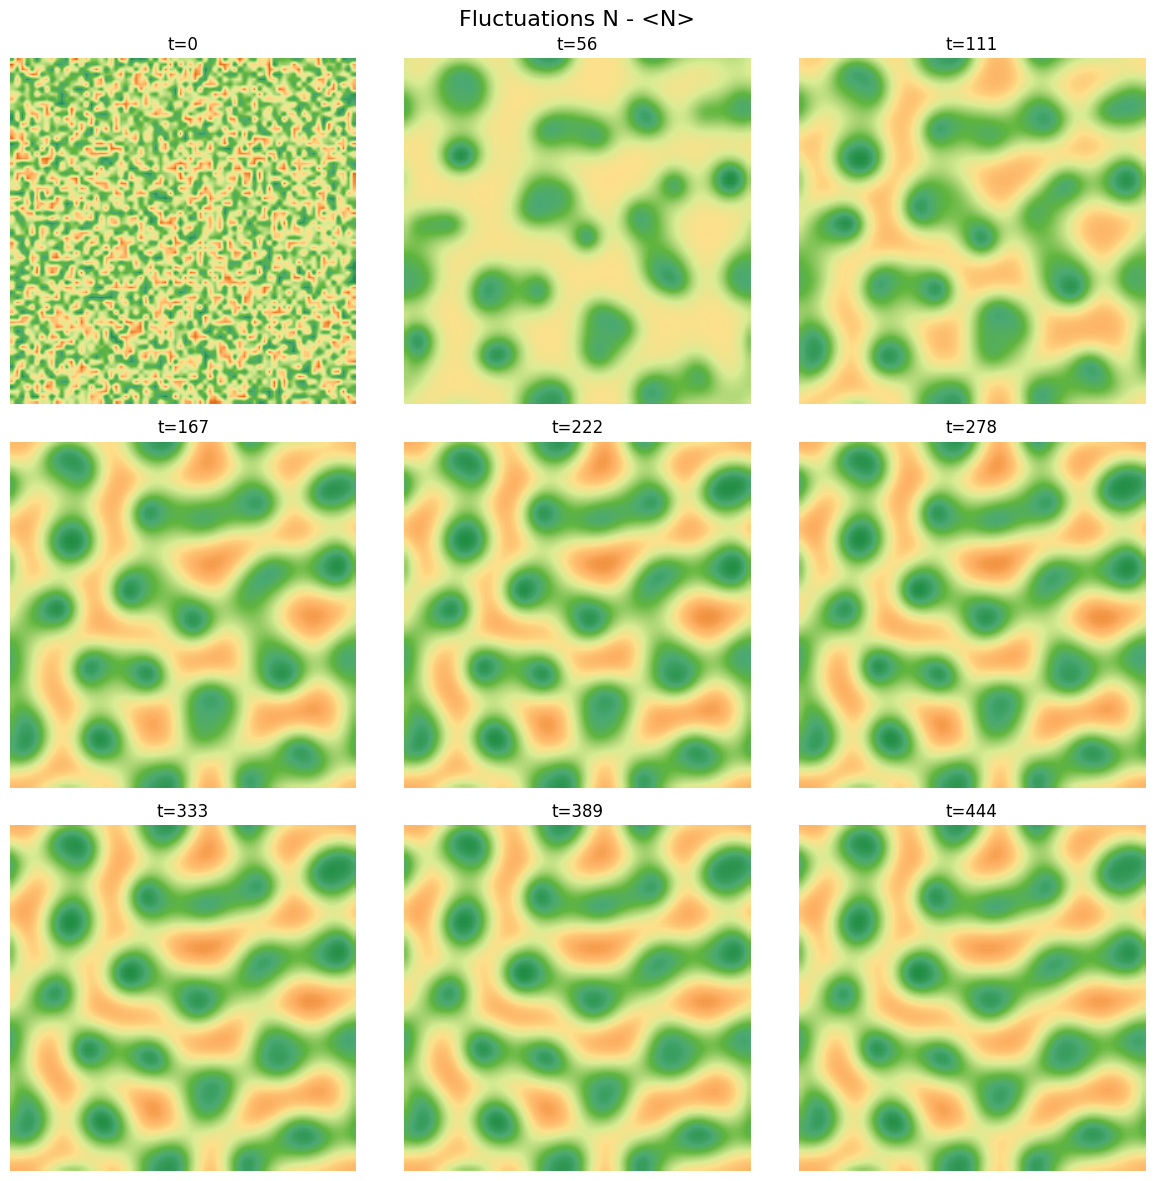

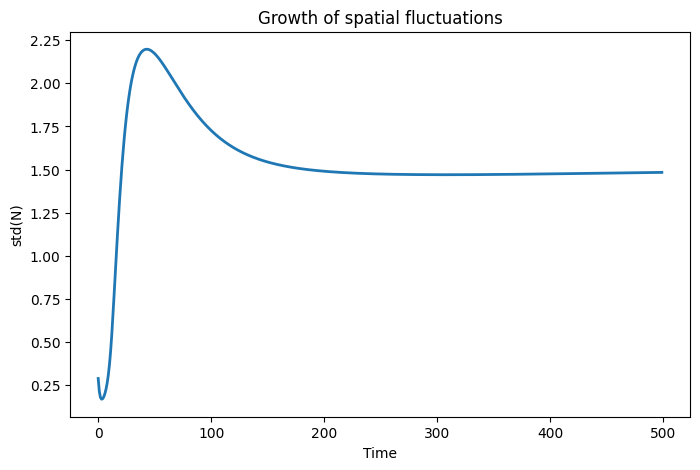

Generating GIF...
GIF saved as simulation.gif


In [20]:
# Parameters
L = 5.0
Ngrid = 70
dx = L / Ngrid

dt = 0.001
nsteps = 500000

dw = 1.0
dn = 0.001
m = 0.08
a = 0.27

np.random.seed(1)

W = np.random.rand(Ngrid, Ngrid)
Nfield = np.random.rand(Ngrid, Ngrid)

# Simulation colors
colors = [
    "#d95f02",  
    "#fdae61",  
    "#fee08b",  
    "#d9ec94",  
    "#a5d271",
    "#60b53e",
    "#4ba973",
    "#218D43",

]

desert_green = mcolors.LinearSegmentedColormap.from_list(
    "desert_green",
    colors,
    N=256
)

# Laplacian
@njit
def laplacian(Z):

    nx, ny = Z.shape
    lap = np.empty_like(Z)

    for i in range(nx):

        ip = (i + 1) % nx
        im = (i - 1) % nx

        for j in range(ny):

            jp = (j + 1) % ny
            jm = (j - 1) % ny

            lap[i, j] = (
                Z[ip, j] +
                Z[im, j] +
                Z[i, jp] +
                Z[i, jm] -
                4 * Z[i, j]
            ) / (dx * dx)

    return lap

# Equations solver
@njit
def step(W, N, a_current, dt, dw, dn, m):

    lapW = laplacian(W)
    lapN = laplacian(N)

    W_new = W + dt * (
        a_current
        - W
        - W * N * N
        + dw * lapW
    )

    N_new = N + dt * (
        W * N * N
        - m * N
        + dn * lapN
    )

    return W_new, N_new


n = 3
total_snapshots = n * n
snapshot_step = nsteps // total_snapshots

snapshots = []
snapshot_times = []

# GIF parameters
gif_frames = []
gif_step = 2000   

# Calculating std temporal to evaluate growth of fluctuations
stds = []
tempos = []

print("Simulation running...")

for i in range(nsteps):

    W, Nfield = step(
        W, Nfield,
        a,
        dt,
        dw, dn, m
    )

    # Snapshots for grid 3x3
    if i % snapshot_step == 0 and len(snapshots) < total_snapshots:

        snapshots.append(Nfield.copy())
        snapshot_times.append(i * dt)

        print(f"snapshot t={i*dt:.0f}")

    # GIF frames
    if i % gif_step == 0:
        gif_frames.append(Nfield.copy())

    # Std temporal
    if i % 1000 == 0:
        stds.append(np.std(Nfield))
        tempos.append(i * dt)

print("Simulation concluded.")

# Plot snapshots

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for k, ax in enumerate(axes.flat):

    field = snapshots[k]

    fluct = field - np.mean(field)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im = ax.imshow(
        fluct,
        cmap=desert_green,
        vmin=-lim,
        vmax=lim,
        interpolation='bilinear',
        extent=[0, L, 0, L]
    )

    ax.set_title(f"t={snapshot_times[k]:.0f}")
    ax.set_axis_off()

plt.suptitle("Fluctuations N - <N>", fontsize=16)
plt.tight_layout()
plt.show()

# Plot std versus time

plt.figure(figsize=(8, 5))

plt.plot(tempos, stds, lw=2)

plt.xlabel("Time")
plt.ylabel("std(N)")
plt.title("Growth of spatial fluctuations")

plt.show()

# Plot GIF

print("Generating GIF...")

fig_gif, ax_gif = plt.subplots(figsize=(6, 6))

field0 = gif_frames[0]

fluct0 = field0 - np.mean(field0)
fluct0 = fluct0 / (np.std(fluct0) + 1e-12)

lim0 = np.max(np.abs(fluct0))

im = ax_gif.imshow(
    fluct0,
    cmap=desert_green,
    vmin=-lim0,
    vmax=lim0,
    interpolation='bilinear',
    extent=[0, L, 0, L],
    animated=True
)

title = ax_gif.set_title("t = 0.0")

ax_gif.set_axis_off()

def update(frame_index):

    frame = gif_frames[frame_index]

    fluct = frame - np.mean(frame)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im.set_array(fluct)
    im.set_clim(-lim, lim)

    # tempo físico correspondente
    current_time = frame_index * gif_step * dt

    title.set_text(f"t = {current_time:.1f}")

    return [im, title]

ani = FuncAnimation(
    fig_gif,
    update,
    frames=len(gif_frames),
    interval=50,
    blit=True
)

ani.save(
    "simulation.gif",
    writer=PillowWriter(fps=20)
)

plt.close()

print("GIF saved as simulation.gif")

#### Applying noise in the system
##### Sum noize
-------

Simulation running...
snapshot t=0
snapshot t=56
snapshot t=111
snapshot t=167
snapshot t=222
snapshot t=278
snapshot t=333
snapshot t=389
snapshot t=444
Simulation concluded.


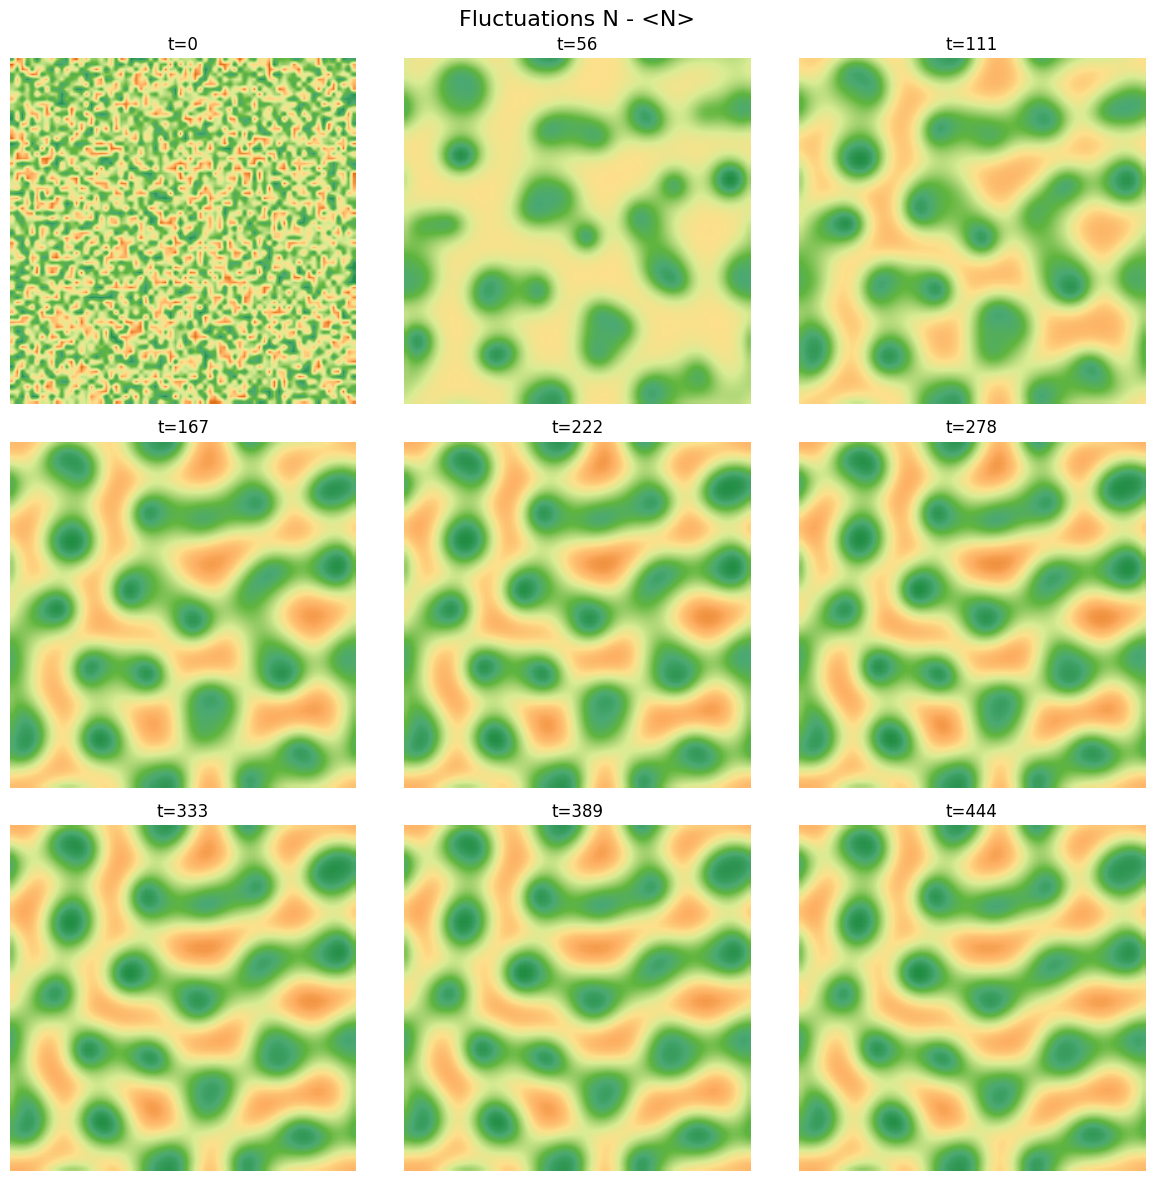

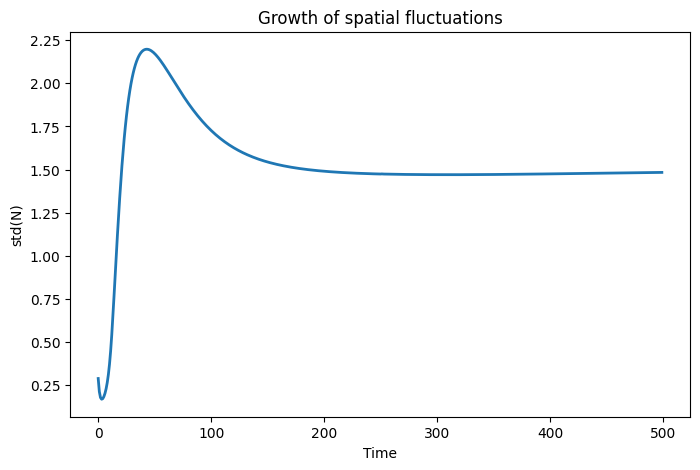

Generating GIF...
GIF saved as simulation_with_rain_sum.gif


In [30]:
# Parameters
L = 5.0
Ngrid = 70
dx = L / Ngrid

dt = 0.001
nsteps = 500000

dw = 1.0
dn = 0.001
m = 0.08
a = 0.27

rain_amp = 10  # intensidade da chuva

np.random.seed(1)

W = np.random.rand(Ngrid, Ngrid)
Nfield = np.random.rand(Ngrid, Ngrid)

# Simulation colors
colors = [
    "#d95f02",  
    "#fdae61",  
    "#fee08b",  
    "#d9ec94",  
    "#a5d271",
    "#60b53e",
    "#4ba973",
    "#218D43",
]

desert_green = mcolors.LinearSegmentedColormap.from_list(
    "desert_green",
    colors,
    N=256
)

# Laplacian
@njit
def laplacian(Z):

    nx, ny = Z.shape
    lap = np.empty_like(Z)

    for i in range(nx):
        ip = (i + 1) % nx
        im = (i - 1) % nx

        for j in range(ny):
            jp = (j + 1) % ny
            jm = (j - 1) % ny

            lap[i, j] = (
                Z[ip, j] +
                Z[im, j] +
                Z[i, jp] +
                Z[i, jm] -
                4 * Z[i, j]
            ) / (dx * dx)

    return lap


# Equations solver
@njit
def step(W, N, a_current, dt, dw, dn, m):

    lapW = laplacian(W)
    lapN = laplacian(N)

    W_new = W + dt * (
        a_current
        - W
        - W * N * N
        + dw * lapW
    )

    N_new = N + dt * (
        W * N * N
        - m * N
        + dn * lapN
    )

    return W_new, N_new

n = 3
total_snapshots = n * n
snapshot_step = nsteps // total_snapshots

snapshots = []
snapshot_times = []

gif_frames = []
gif_step = 2000   

stds = []
tempos = []

print("Simulation running...")

for i in range(nsteps):

    t = i * dt

    if 250 <= t <= 251:
        rain = rain_amp * np.random.randn(*W.shape)
        a_effective = a + rain
    else:
        a_effective = a

    W, Nfield = step(
        W, Nfield,
        a_effective,
        dt,
        dw, dn, m
    )

    # Snapshots
    if i % snapshot_step == 0 and len(snapshots) < total_snapshots:
        snapshots.append(Nfield.copy())
        snapshot_times.append(i * dt)
        print(f"snapshot t={i*dt:.0f}")

    # GIF frames
    if i % gif_step == 0:
        gif_frames.append(Nfield.copy())

    # Std temporal
    if i % 1000 == 0:
        stds.append(np.std(Nfield))
        tempos.append(i * dt)

print("Simulation concluded.")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for k, ax in enumerate(axes.flat):

    field = snapshots[k]

    fluct = field - np.mean(field)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im = ax.imshow(
        fluct,
        cmap=desert_green,
        vmin=-lim,
        vmax=lim,
        interpolation='bilinear',
        extent=[0, L, 0, L]
    )

    ax.set_title(f"t={snapshot_times[k]:.0f}")
    ax.set_axis_off()

plt.suptitle("Fluctuations N - <N>", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tempos, stds, lw=2)
plt.xlabel("Time")
plt.ylabel("std(N)")
plt.title("Growth of spatial fluctuations")
plt.show()

print("Generating GIF...")

fig_gif, ax_gif = plt.subplots(figsize=(6, 6))

field0 = gif_frames[0]

fluct0 = field0 - np.mean(field0)
fluct0 = fluct0 / (np.std(fluct0) + 1e-12)

lim0 = np.max(np.abs(fluct0))

im = ax_gif.imshow(
    fluct0,
    cmap=desert_green,
    vmin=-lim0,
    vmax=lim0,
    interpolation='bilinear',
    extent=[0, L, 0, L],
    animated=True
)

title = ax_gif.set_title("t = 0.0")
ax_gif.set_axis_off()


def update(frame_index):

    frame = gif_frames[frame_index]

    fluct = frame - np.mean(frame)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im.set_array(fluct)
    im.set_clim(-lim, lim)

    current_time = frame_index * gif_step * dt
    title.set_text(f"t = {current_time:.1f}")

    return [im, title]


ani = FuncAnimation(
    fig_gif,
    update,
    frames=len(gif_frames),
    interval=50,
    blit=True
)

ani.save(
    "simulation_with_rain_sum.gif",
    writer=PillowWriter(fps=20)
)

plt.close()

print("GIF saved as simulation_with_rain_sum.gif")

#### Adding multiplicative noise
____


Simulation running...
snapshot t=0
snapshot t=56
snapshot t=111
snapshot t=167
snapshot t=222
snapshot t=278
snapshot t=333
snapshot t=389
snapshot t=444
Simulation concluded.


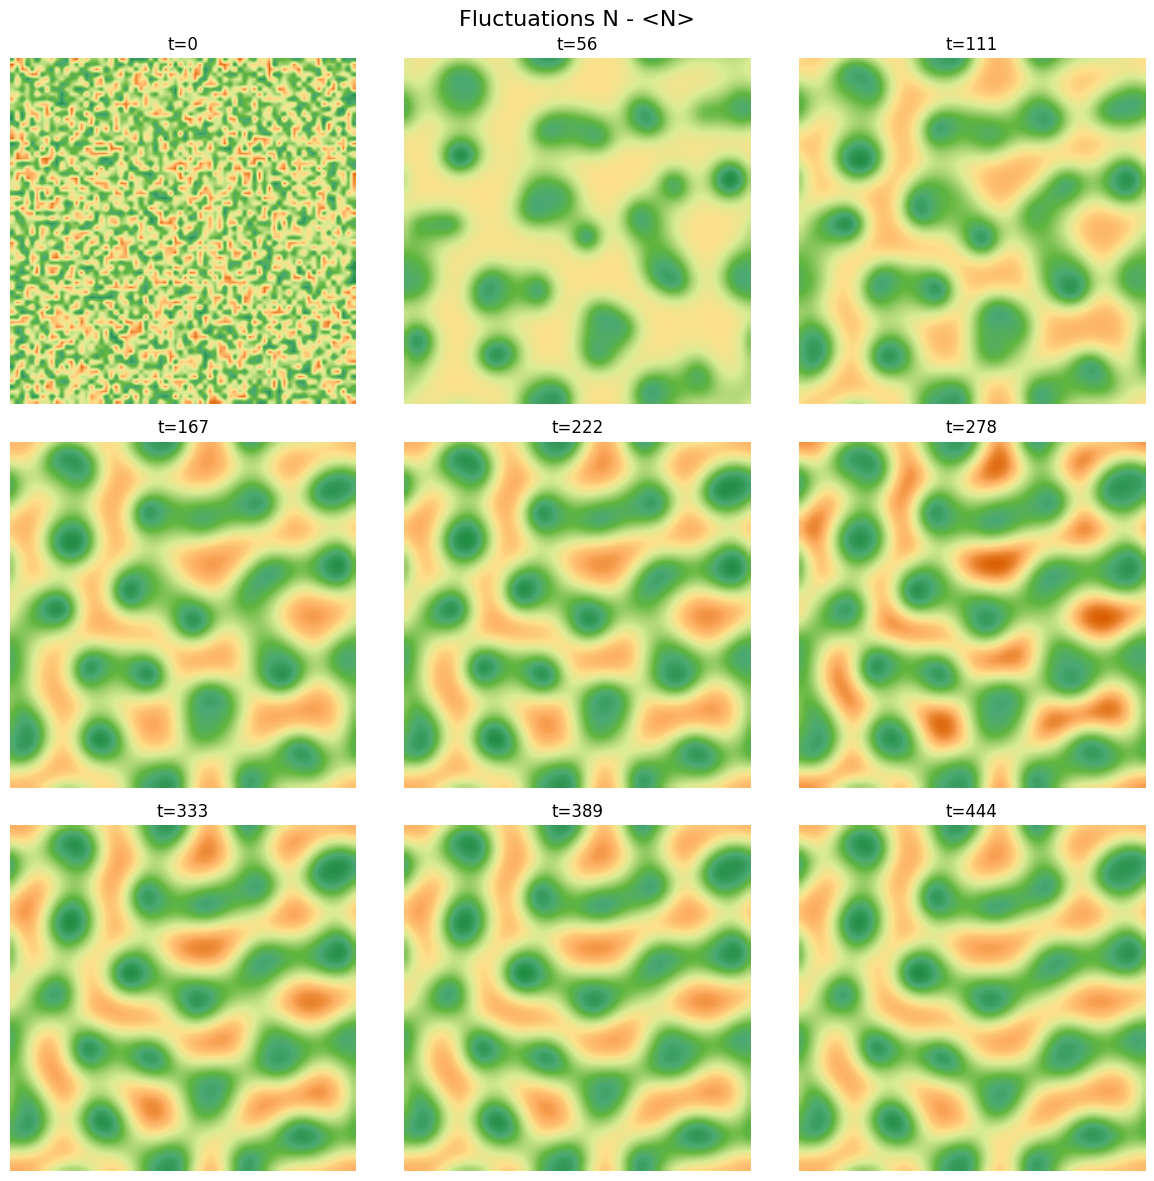

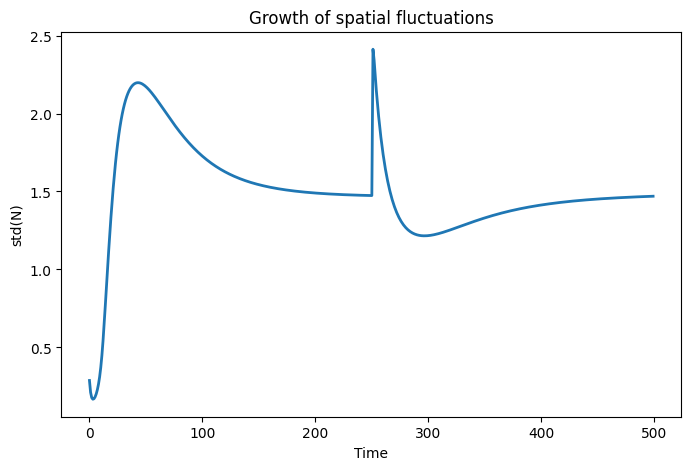

Generating GIF...
GIF saved as simulation_with_rain_lognormal.gif


In [31]:
# Parameters
L = 5.0
Ngrid = 70
dx = L / Ngrid

dt = 0.001
nsteps = 500000

dw = 1.0
dn = 0.001
m = 0.08
a = 0.27

rain_amp = 2  # Noise amplitude

np.random.seed(1)

W = np.random.rand(Ngrid, Ngrid)
Nfield = np.random.rand(Ngrid, Ngrid)

# Simulation colors
colors = [
    "#d95f02",  
    "#fdae61",  
    "#fee08b",  
    "#d9ec94",  
    "#a5d271",
    "#60b53e",
    "#4ba973",
    "#218D43",
]

desert_green = mcolors.LinearSegmentedColormap.from_list(
    "desert_green",
    colors,
    N=256
)

# Laplacian
@njit
def laplacian(Z):

    nx, ny = Z.shape
    lap = np.empty_like(Z)

    for i in range(nx):
        ip = (i + 1) % nx
        im = (i - 1) % nx

        for j in range(ny):
            jp = (j + 1) % ny
            jm = (j - 1) % ny

            lap[i, j] = (
                Z[ip, j] +
                Z[im, j] +
                Z[i, jp] +
                Z[i, jm] -
                4 * Z[i, j]
            ) / (dx * dx)

    return lap


# Equations solver
@njit
def step(W, N, a_current, dt, dw, dn, m):

    lapW = laplacian(W)
    lapN = laplacian(N)

    W_new = W + dt * (
        a_current
        - W
        - W * N * N
        + dw * lapW
    )

    N_new = N + dt * (
        W * N * N
        - m * N
        + dn * lapN
    )

    return W_new, N_new

n = 3
total_snapshots = n * n
snapshot_step = nsteps // total_snapshots

snapshots = []
snapshot_times = []

gif_frames = []
gif_step = 2000   

stds = []
tempos = []

print("Simulation running...")

for i in range(nsteps):

    t = i * dt

    if 250 <= t <= 251:
        noise = rain_amp * np.random.randn(*W.shape)
        a_effective = a * np.exp(noise)   # multiplicativo log-normal
    else:
        a_effective = a

    W, Nfield = step(
        W, Nfield,
        a_effective,
        dt,
        dw, dn, m
    )

    # Snapshots
    if i % snapshot_step == 0 and len(snapshots) < total_snapshots:
        snapshots.append(Nfield.copy())
        snapshot_times.append(i * dt)
        print(f"snapshot t={i*dt:.0f}")

    # GIF frames
    if i % gif_step == 0:
        gif_frames.append(Nfield.copy())

    # Std temporal
    if i % 1000 == 0:
        stds.append(np.std(Nfield))
        tempos.append(i * dt)

print("Simulation concluded.")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for k, ax in enumerate(axes.flat):

    field = snapshots[k]

    fluct = field - np.mean(field)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im = ax.imshow(
        fluct,
        cmap=desert_green,
        vmin=-lim,
        vmax=lim,
        interpolation='bilinear',
        extent=[0, L, 0, L]
    )

    ax.set_title(f"t={snapshot_times[k]:.0f}")
    ax.set_axis_off()

plt.suptitle("Fluctuations N - <N>", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tempos, stds, lw=2)
plt.xlabel("Time")
plt.ylabel("std(N)")
plt.title("Growth of spatial fluctuations")
plt.show()

print("Generating GIF...")

fig_gif, ax_gif = plt.subplots(figsize=(6, 6))

field0 = gif_frames[0]

fluct0 = field0 - np.mean(field0)
fluct0 = fluct0 / (np.std(fluct0) + 1e-12)

lim0 = np.max(np.abs(fluct0))

im = ax_gif.imshow(
    fluct0,
    cmap=desert_green,
    vmin=-lim0,
    vmax=lim0,
    interpolation='bilinear',
    extent=[0, L, 0, L],
    animated=True
)

title = ax_gif.set_title("t = 0.0")
ax_gif.set_axis_off()


def update(frame_index):

    frame = gif_frames[frame_index]

    fluct = frame - np.mean(frame)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im.set_array(fluct)
    im.set_clim(-lim, lim)

    current_time = frame_index * gif_step * dt
    title.set_text(f"t = {current_time:.1f}")

    return [im, title]


ani = FuncAnimation(
    fig_gif,
    update,
    frames=len(gif_frames),
    interval=50,
    blit=True
)

ani.save(
    "simulation_with_rain_lognormal.gif",
    writer=PillowWriter(fps=20)
)

plt.close()

print("GIF saved as simulation_with_rain_lognormal.gif")

#### Adding spatial structured noise
-----

Simulation running...
snapshot t=0
snapshot t=56
snapshot t=111
snapshot t=167
snapshot t=222
snapshot t=278
snapshot t=333
snapshot t=389
snapshot t=444
Simulation concluded.


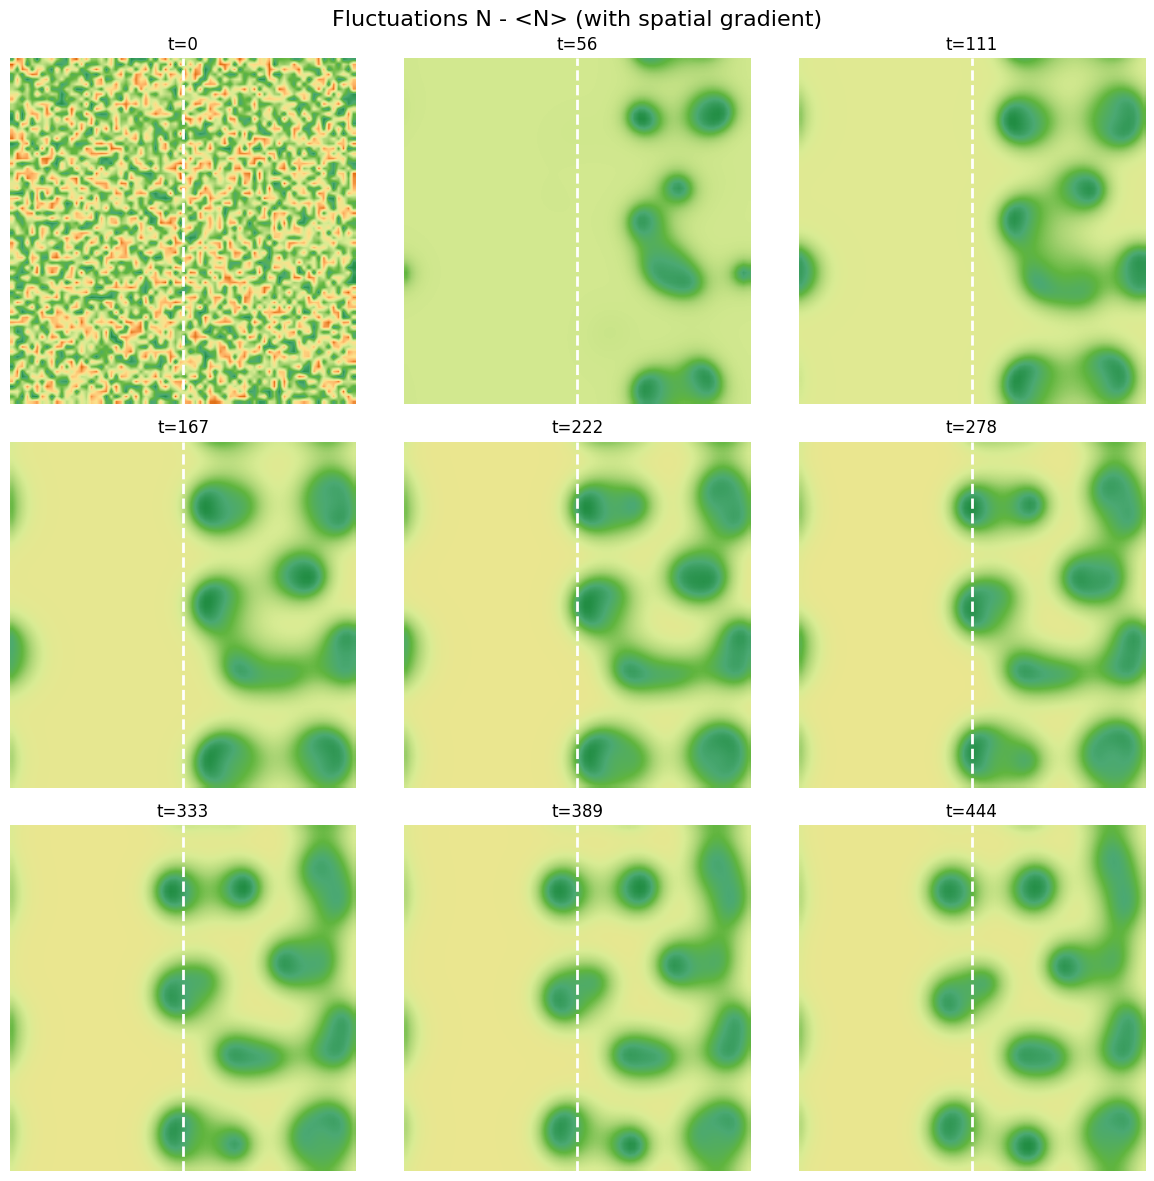

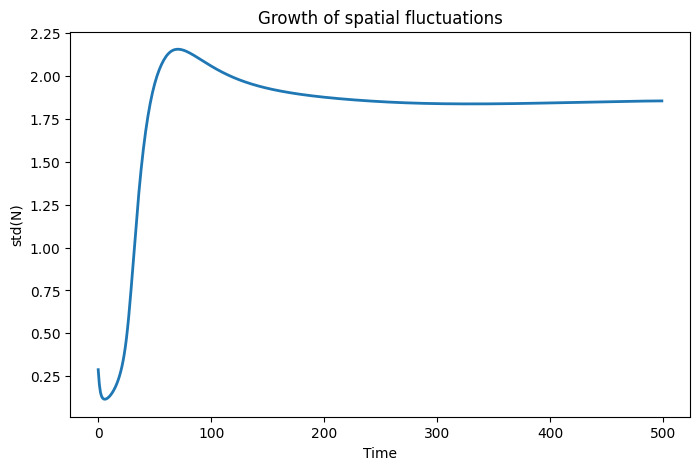

Generating GIF...
GIF saved as simulation_with_noise_2regions.gif


In [32]:
# Parameters
L = 5.0
Ngrid = 70
dx = L / Ngrid

dt = 0.001
nsteps = 500000

dw = 1.0
dn = 0.001
m = 0.08
a = 0.27

np.random.seed(1)

W = np.random.rand(Ngrid, Ngrid)
Nfield = np.random.rand(Ngrid, Ngrid)

x = np.linspace(0, 1, Ngrid) # adding area
X, Y = np.meshgrid(x, x)

rain_gradient = 0.2 + 0.8 * X

# Colors
colors = [
    "#d95f02",  
    "#fdae61",  
    "#fee08b",  
    "#d9ec94",  
    "#a5d271",
    "#60b53e",
    "#4ba973",
    "#218D43",
]

desert_green = mcolors.LinearSegmentedColormap.from_list(
    "desert_green",
    colors,
    N=256
)

# Laplacian
@njit
def laplacian(Z):

    nx, ny = Z.shape
    lap = np.empty_like(Z)

    for i in range(nx):
        ip = (i + 1) % nx
        im = (i - 1) % nx

        for j in range(ny):
            jp = (j + 1) % ny
            jm = (j - 1) % ny

            lap[i, j] = (
                Z[ip, j] +
                Z[im, j] +
                Z[i, jp] +
                Z[i, jm] -
                4 * Z[i, j]
            ) / (dx * dx)

    return lap


# Solver
@njit
def step(W, N, a_current, dt, dw, dn, m):

    lapW = laplacian(W)
    lapN = laplacian(N)

    W_new = W + dt * (
        a_current
        - W
        - W * N * N
        + dw * lapW
    )

    N_new = N + dt * (
        W * N * N
        - m * N
        + dn * lapN
    )

    return W_new, N_new

n = 3
total_snapshots = n * n
snapshot_step = nsteps // total_snapshots

snapshots = []
snapshot_times = []

gif_frames = []
gif_step = 2000   

stds = []
tempos = []

print("Simulation running...")

for i in range(nsteps):

    a_field = a * rain_gradient

    W, Nfield = step(
        W, Nfield,
        a_field,
        dt,
        dw, dn, m
    )

    # Snapshots
    if i % snapshot_step == 0 and len(snapshots) < total_snapshots:
        snapshots.append(Nfield.copy())
        snapshot_times.append(i * dt)
        print(f"snapshot t={i*dt:.0f}")

    # GIF
    if i % gif_step == 0:
        gif_frames.append(Nfield.copy())

    # std
    if i % 1000 == 0:
        stds.append(np.std(Nfield))
        tempos.append(i * dt)

print("Simulation concluded.")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for k, ax in enumerate(axes.flat):

    field = snapshots[k]

    fluct = field - np.mean(field)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im = ax.imshow(
        fluct,
        cmap=desert_green,
        vmin=-lim,
        vmax=lim,
        interpolation='bilinear',
        extent=[0, L, 0, L]
    )

    ax.axvline(x=L/2, color="white", linestyle="--", linewidth=2)

    ax.set_title(f"t={snapshot_times[k]:.0f}")
    ax.set_axis_off()

plt.suptitle("Fluctuations N - <N> (with spatial gradient)", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tempos, stds, lw=2)
plt.xlabel("Time")
plt.ylabel("std(N)")
plt.title("Growth of spatial fluctuations")
plt.show()

print("Generating GIF...")

fig_gif, ax_gif = plt.subplots(figsize=(6, 6))

field0 = gif_frames[0]

fluct0 = field0 - np.mean(field0)
fluct0 = fluct0 / (np.std(fluct0) + 1e-12)

lim0 = np.max(np.abs(fluct0))

im = ax_gif.imshow(
    fluct0,
    cmap=desert_green,
    vmin=-lim0,
    vmax=lim0,
    interpolation='bilinear',
    extent=[0, L, 0, L],
    animated=True
)

ax_gif.axvline(x=L/2, color="white", linestyle="--", linewidth=2)

title = ax_gif.set_title("t = 0.0")
ax_gif.set_axis_off()


def update(frame_index):

    frame = gif_frames[frame_index]

    fluct = frame - np.mean(frame)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im.set_array(fluct)
    im.set_clim(-lim, lim)

    current_time = frame_index * gif_step * dt
    title.set_text(f"t = {current_time:.1f}")

    return [im, title]


ani = FuncAnimation(
    fig_gif,
    update,
    frames=len(gif_frames),
    interval=50,
    blit=True
)

ani.save(
    "simulation_with_noise_2regions.gif",
    writer=PillowWriter(fps=20)
)

plt.close()

print("GIF saved as simulation_with_noise_2regions.gif")

#### Adding noise directly in the field
----

Simulation running...
snapshot t=0
snapshot t=56
snapshot t=111
snapshot t=167
snapshot t=222
snapshot t=278
snapshot t=333
snapshot t=389
snapshot t=444
Simulation concluded.


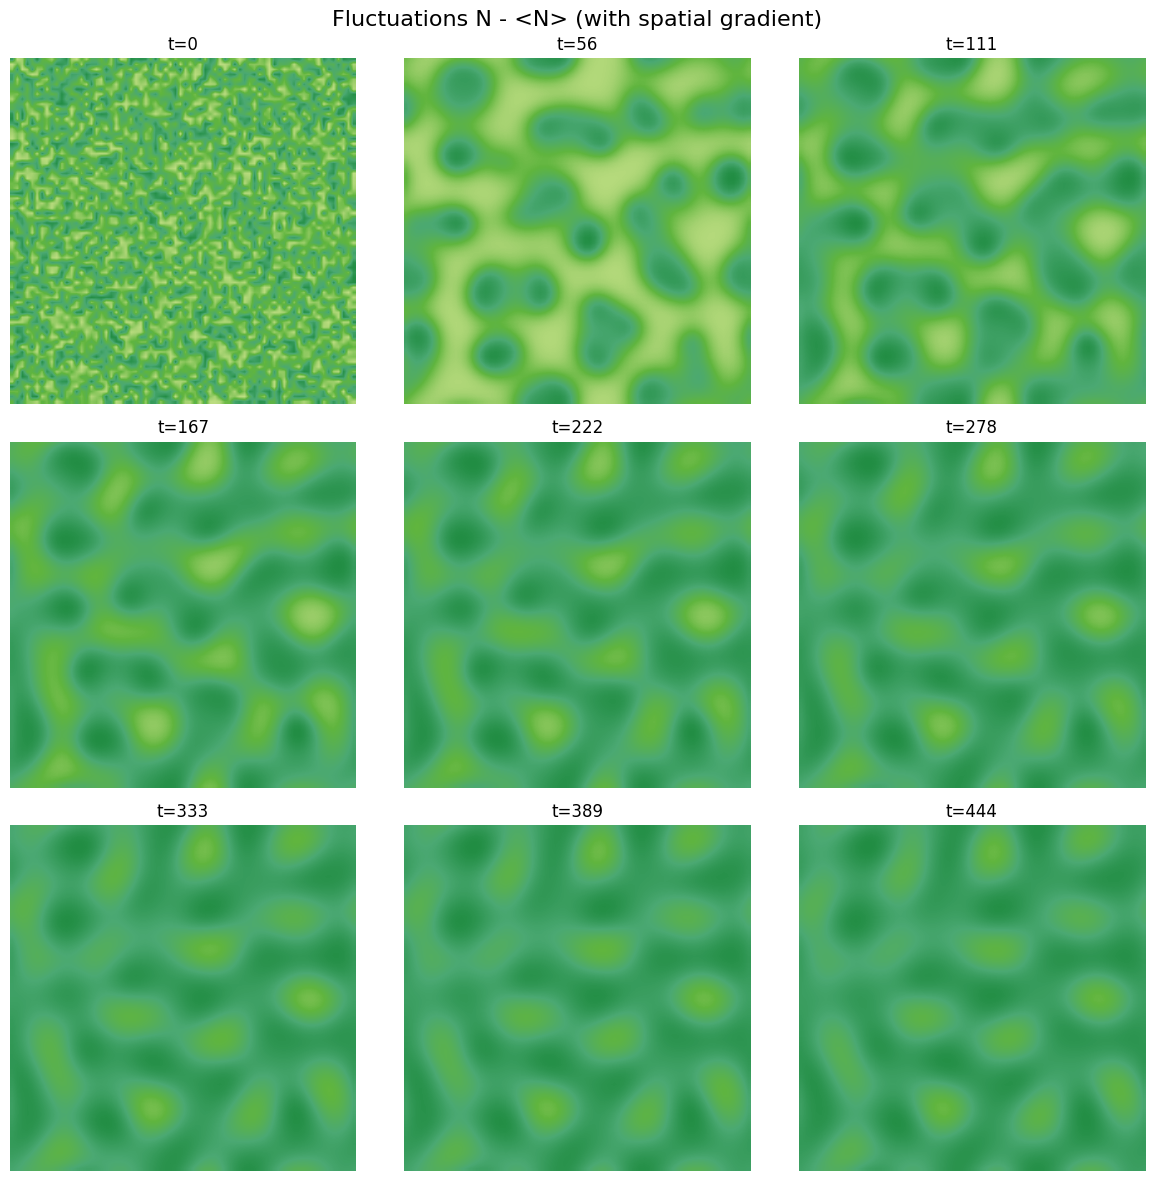

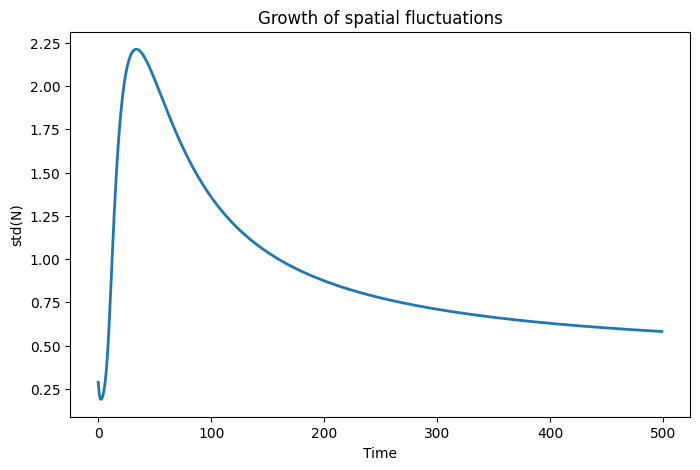

Generating GIF...
GIF saved as simulation_with_spatial_noise.gif


In [4]:
# Parameters
L = 5.0
Ngrid = 70
dx = L / Ngrid

dt = 0.001
nsteps = 500000

dw = 1.0
dn = 0.001
m = 0.08
a = 0.32

sigma = 0.0#5  # noise amplitude 

np.random.seed(1)

W = np.random.rand(Ngrid, Ngrid)
Nfield = np.random.rand(Ngrid, Ngrid)

# Simulation colors
colors = [
    "#d95f02",  
    "#fdae61",  
    "#fee08b",  
    "#d9ec94",  
    "#a5d271",
    "#60b53e",
    "#4ba973",
    "#218D43",
]

desert_green = mcolors.LinearSegmentedColormap.from_list(
    "desert_green",
    colors,
    N=256
)

@njit
def laplacian(Z):

    nx, ny = Z.shape
    lap = np.empty_like(Z)

    for i in range(nx):

        ip = (i + 1) % nx
        im = (i - 1) % nx

        for j in range(ny):

            jp = (j + 1) % ny
            jm = (j - 1) % ny

            lap[i, j] = (
                Z[ip, j] +
                Z[im, j] +
                Z[i, jp] +
                Z[i, jm] -
                4 * Z[i, j]
            ) / (dx * dx)

    return lap


@njit
def step(W, N, a_current, dt, dw, dn, m):

    lapW = laplacian(W)
    lapN = laplacian(N)

    W_new = W + dt * (
        a_current
        - W
        - W * N * N
        + dw * lapW
    )

    N_new = N + dt * (
        W * N * N
        - m * N
        + dn * lapN
    )

    return W_new, N_new

n = 3
total_snapshots = n * n
snapshot_step = nsteps // total_snapshots

snapshots = []
snapshot_times = []

gif_frames = []
gif_step = 2000   

stds = []
tempos = []

print("Simulation running...")

for i in range(nsteps):

    W, Nfield = step(W, Nfield, a, dt, dw, dn, m)

    W = W + sigma * np.random.randn(*W.shape)

    if i % snapshot_step == 0 and len(snapshots) < total_snapshots:
        snapshots.append(Nfield.copy())
        snapshot_times.append(i * dt)
        print(f"snapshot t={i*dt:.0f}")

    if i % gif_step == 0:
        gif_frames.append(Nfield.copy())

    if i % 1000 == 0:
        stds.append(np.std(Nfield))
        tempos.append(i * dt)

print("Simulation concluded.")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for k, ax in enumerate(axes.flat):

    field = snapshots[k]

    fluct = field# - np.mean(field)
    fluct = fluct# / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im = ax.imshow(
        fluct,
        cmap=desert_green,
        vmin=-lim,
        vmax=lim,
        interpolation='bilinear',
        extent=[0, L, 0, L]
    )


    ax.set_title(f"t={snapshot_times[k]:.0f}")
    ax.set_axis_off()

plt.suptitle("Fluctuations N - <N> (with spatial gradient)", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tempos, stds, lw=2)
plt.xlabel("Time")
plt.ylabel("std(N)")
plt.title("Growth of spatial fluctuations")
plt.show()

print("Generating GIF...")

fig_gif, ax_gif = plt.subplots(figsize=(6, 6))

field0 = gif_frames[0]

fluct0 = field0# - np.mean(field0)
fluct0 = fluct0# / (np.std(fluct0) + 1e-12)

lim0 = np.max(np.abs(fluct0))

im = ax_gif.imshow(
    fluct0,
    cmap=desert_green,
    vmin=-lim0,
    vmax=lim0,
    interpolation='bilinear',
    extent=[0, L, 0, L],
    animated=True
)

title = ax_gif.set_title("t = 0.0")
ax_gif.set_axis_off()


def update(frame_index):

    frame = gif_frames[frame_index]

    fluct = frame# - np.mean(frame)
    fluct = fluct# / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im.set_array(fluct)
    im.set_clim(-lim, lim)

    current_time = frame_index * gif_step * dt
    title.set_text(f"t = {current_time:.1f}")

    return [im, title]


ani = FuncAnimation(
    fig_gif,
    update,
    frames=len(gif_frames),
    interval=50,
    blit=True
)

ani.save(
    "simulation_with_spatial_noise.gif",
    writer=PillowWriter(fps=20)
)

plt.close()

print("GIF saved as simulation_with_spatial_noise.gif")